# Actualización Selectiva del Pipeline bajo Drift — Physionet (Sepsis)

Evalúa estrategias de respuesta ante drift sintético sobre un pipeline
de **dos etapas** entrenado en datos de referencia:

| ID      | Estrategia               | Descripción                                                                            |
| ------- | ------------------------ | -------------------------------------------------------------------------------------- |
| **A1**  | **Defer**                | No hacer nada — usar pipeline original                                                 |
| **A2**  | **Actualizar features**  | Reajustar Stage 1 (QuantileTransformer) con datos nuevos, mantener modelo              |
| **A2c** | **Features correctivos** | Corregir datos drifteados hacia referencia, aplicar Stage 1 original y mantener modelo |
| **A3**  | **Actualizar modelo**    | Mantener Stage 1 original, reentrenar XGBoost con datos nuevos                         |
| **A4**  | **Reentrenar todo**      | Reajustar Stage 1 y reentrenar XGBoost — referencia de costo máximo                    |

**Métrica de recuperación:**
$$\text{Rec}\% = \frac{\text{AUC}_{\text{estrategia}}}{\text{AUC}_{\text{baseline}}} \times 100$$

**Costo:** tiempo relativo a A4 (1.00×).

**Acción óptima:** estrategia con menor costo total residual + cómputo.


## Pipeline de dos etapas

$$\hat{y} = f_2 \left( f_1(X) \right)$$

Donde:

- $f_1$ — **Stage 1**: `QuantileTransformer` ajustado sobre VITALS del conjunto de referencia.
- $f_2$ — **Stage 2**: `XGBClassifier` ajustado sobre la salida de $f_1$.

Cuando ocurre drift, el diagnóstico determina si actualizar $f_1$ (covariate), $f_2$ (concept) o ambas (both).


## 1. Imports y configuración


In [1]:
import warnings, time

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
)
from sklearn.preprocessing import QuantileTransformer
from xgboost import XGBClassifier

from darl.data.get_dataset import load_dataset, find_project_root
from darl.drift import DriftInjector
from darl.visualization.drift_plots import plot_numeric_drift_grid

SEED = 42
np.random.seed(SEED)

# Variables de signos vitales — Stage 1 (QuantileTransformer)
VITALS = ["HR", "SBP", "MAP", "Resp", "Temp"]

# Configuración de drift por variable
NUM_CFG = {
    "HR": "high",
    "SBP": "low",
    "MAP": "low",
    "Resp": "high",
    "Temp": "extreme",
}

LABEL_COL = "SepsisLabel"

# Usamos el set de entrenamiento completo para reentrenar (A3/A4)

print("Imports OK")

Imports OK


## 2. Carga del dataset Physionet


In [2]:
dset = load_dataset("physionet")

X_train, y_train, _, _ = dset.get_pandas(split="train")
X_test, y_test, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values

df_target = X_test.copy()
df_target[LABEL_COL] = y_test.values

NUMERIC_COLS = (
    df_train.drop(columns=[LABEL_COL])
    .select_dtypes(include=["number"])
    .columns.tolist()
)

print(f"Train  : {df_train.shape}")
print(f"Target : {df_target.shape}")
print(f"Features numericas: {len(NUMERIC_COLS)}")
print(f"Prevalencia Sepsis Train : {y_train.mean():.4f}")
print(f"Prevalencia Sepsis Target: {y_test.mean():.4f}")
print(f"VITALS presentes: {[c for c in VITALS if c in df_target.columns]}")

Train  : (1122299, 41)
Target : (140288, 41)
Features numericas: 39
Prevalencia Sepsis Train : 0.0118
Prevalencia Sepsis Target: 0.0120
VITALS presentes: ['HR', 'SBP', 'MAP', 'Resp', 'Temp']


## 3. Entrenamiento del Pipeline Baseline (dos etapas)

- **Stage 1**: `QuantileTransformer` ajustado sobre VITALS de `df_train`
- **Stage 2**: `XGBClassifier` ajustado sobre datos transformados por Stage 1


In [3]:
# ─── Stage 1: QuantileTransformer sobre VITALS ───
qt_ref = QuantileTransformer(
    n_quantiles=500,
    output_distribution="normal",
    random_state=SEED,
)
qt_ref.fit(df_train[VITALS])


def apply_stage1(df: pd.DataFrame, qt: QuantileTransformer) -> pd.DataFrame:
    """Aplica QuantileTransformer sobre VITALS y devuelve DataFrame completo."""
    out = df.copy()
    vitals_present = [c for c in VITALS if c in out.columns]
    out[vitals_present] = qt.transform(out[vitals_present])
    return out


# ─── Stage 2: XGBoost sobre datos transformados ───
df_train_t = apply_stage1(df_train, qt_ref)
X_tr = df_train_t[NUMERIC_COLS].values
y_tr = df_train_t[LABEL_COL].values

neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(
    f"Clase 0: {neg:,}  |  Clase 1: {pos:,}  |  scale_pos_weight={SCALE_POS_WEIGHT:.1f}"
)


def make_xgb() -> XGBClassifier:
    """Crea XGBClassifier con hiperparámetros fijos."""
    return XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )


model_ref = make_xgb()
model_ref.fit(X_tr, y_tr)
print("Pipeline baseline entrenado.")

Clase 0: 1,109,051  |  Clase 1: 13,248  |  scale_pos_weight=83.7
Pipeline baseline entrenado.


## 4. Evaluación Baseline

Umbral óptimo calculado maximizando F1 sobre el test set limpio.


In [4]:
df_target_t = apply_stage1(df_target, qt_ref)
X_te = df_target_t[NUMERIC_COLS].values
y_te = df_target_t[LABEL_COL].values

y_prob_base = model_ref.predict_proba(X_te)[:, 1]

AUC_BASE = roc_auc_score(y_te, y_prob_base)
AUPR_BASE = average_precision_score(y_te, y_prob_base)

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te, y_prob_base)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
BEST_THRESHOLD = float(thresh_arr[f1_arr.argmax()])

y_pred_base = (y_prob_base >= BEST_THRESHOLD).astype(int)
F1_BASE = f1_score(y_te, y_pred_base)

print(f"AUC-ROC baseline         : {AUC_BASE:.4f}")
print(f"AUC-PR  baseline         : {AUPR_BASE:.4f}")
print(f"Umbral optimo (F1)       : {BEST_THRESHOLD:.4f}")
print(f"F1-score (umbral optimo) : {F1_BASE:.4f}")
print()
print(classification_report(y_te, y_pred_base))

AUC-ROC baseline         : 0.7836
AUC-PR  baseline         : 0.0667
Umbral optimo (F1)       : 0.7613
F1-score (umbral optimo) : 0.1350

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    138598
           1       0.10      0.21      0.14      1690

    accuracy                           0.97    140288
   macro avg       0.54      0.59      0.56    140288
weighted avg       0.98      0.97      0.97    140288



## 5. Ajuste del DriftInjector


In [5]:
inj = DriftInjector(random_state=SEED)
inj.fit(df_train, numeric_cols=VITALS)
print(f"DriftInjector ajustado sobre VITALS: {inj._numeric_cols}")

DriftInjector ajustado sobre VITALS: ['HR', 'SBP', 'MAP', 'Resp', 'Temp']


## 6. Definición de Estrategias A1–A4

Cada estrategia recibe los datos drifteados y el conjunto de entrenamiento
drifteado (para reajuste), y devuelve métricas + tiempo de ejecución.

|     | Stage 1 (QT)   | Stage 2 (XGB)   |
| --- | -------------- | --------------- |
| A1  | original       | original        |
| A2  | **reajustado** | original        |
| A3  | original       | **reentrenado** |
| A4  | **reajustado** | **reentrenado** |


In [ ]:
def eval_metrics(model, X, y, threshold):
    """Evalua AUC, AUPR y F1 con umbral dado."""
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    aupr = average_precision_score(y, y_prob)
    f1 = f1_score(y, (y_prob >= threshold).astype(int))
    return {"auc": auc, "aupr": aupr, "f1": f1}


def fit_reference_quantile_map(
    source_df: pd.DataFrame,
    reference_df: pd.DataFrame,
    cols: list[str],
    n_quantiles: int = 501,
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """Aprende un mapeo marginal source -> reference para columnas numericas."""
    probs = np.linspace(0.0, 1.0, n_quantiles)
    qmap = {}

    for col in cols:
        if col not in source_df.columns or col not in reference_df.columns:
            continue

        src = source_df[col].dropna().to_numpy(dtype=float)
        ref = reference_df[col].dropna().to_numpy(dtype=float)
        if len(src) < 2 or len(ref) < 2:
            continue

        src_q = np.quantile(src, probs)
        ref_q = np.quantile(ref, probs)
        src_q, idx = np.unique(src_q, return_index=True)
        ref_q = ref_q[idx]
        if len(src_q) >= 2:
            qmap[col] = (src_q, ref_q)

    return qmap


def apply_reference_quantile_map(
    df: pd.DataFrame,
    qmap: dict[str, tuple[np.ndarray, np.ndarray]],
) -> pd.DataFrame:
    """Mapea columnas drifteadas a la escala marginal de referencia."""
    out = df.copy()

    for col, (src_q, ref_q) in qmap.items():
        values = out[col].to_numpy(dtype=float, copy=True)
        mask = np.isfinite(values)
        values[mask] = np.interp(
            values[mask], src_q, ref_q, left=ref_q[0], right=ref_q[-1]
        )
        out[col] = values

    return out


def run_a1(df_drifted_target, qt, model):
    """A1 — Defer: pipeline original sin cambios (costo de actualizacion = 0)."""
    df_t = apply_stage1(df_drifted_target, qt)
    X = df_t[NUMERIC_COLS].values
    y = df_drifted_target[LABEL_COL].values
    metrics = eval_metrics(model, X, y, BEST_THRESHOLD)
    return metrics, 0.0  # Sin costo de actualizacion


def run_a2(df_drifted_target, df_drifted_train, qt_ref, model):
    """A2 — Actualizar Stage 1: reajustar QT con datos nuevos, mantener XGB."""
    qt_new = QuantileTransformer(
        n_quantiles=500, output_distribution="normal", random_state=SEED
    )
    vitals_present = [c for c in VITALS if c in df_drifted_train.columns]

    t0 = time.perf_counter()
    qt_new.fit(df_drifted_train[vitals_present])
    t_fit = time.perf_counter() - t0

    df_t = apply_stage1(df_drifted_target, qt_new)
    X = df_t[NUMERIC_COLS].values
    y = df_drifted_target[LABEL_COL].values
    metrics = eval_metrics(model, X, y, BEST_THRESHOLD)
    return metrics, t_fit


def run_a2_corrective(
    df_drifted_target, df_drifted_train, df_reference_train, qt_ref, model
):
    """A2c — Corregir X hacia referencia, usar QT original y mantener XGB."""
    t0 = time.perf_counter()
    qmap = fit_reference_quantile_map(df_drifted_train, df_reference_train, VITALS)
    df_corrected_target = apply_reference_quantile_map(df_drifted_target, qmap)
    t_update = time.perf_counter() - t0

    df_t = apply_stage1(df_corrected_target, qt_ref)
    X = df_t[NUMERIC_COLS].values
    y = df_drifted_target[LABEL_COL].values
    metrics = eval_metrics(model, X, y, BEST_THRESHOLD)
    return metrics, t_update


def run_a3(df_drifted_target, df_drifted_train, qt_ref):
    """A3 — Actualizar Stage 2: Stage 1 original, reentrenar XGB con datos nuevos."""
    # Transformar datos nuevos con QT original (operacion gratuita/inferencia)
    df_tr_t = apply_stage1(df_drifted_train, qt_ref)
    X_new = df_tr_t[NUMERIC_COLS].values
    y_new = df_drifted_train[LABEL_COL].values

    model_new = make_xgb()
    t0 = time.perf_counter()
    model_new.fit(X_new, y_new)
    t_fit = time.perf_counter() - t0

    # Evaluar sobre target drifteado con QT original
    df_t = apply_stage1(df_drifted_target, qt_ref)
    X = df_t[NUMERIC_COLS].values
    y = df_drifted_target[LABEL_COL].values
    metrics = eval_metrics(model_new, X, y, BEST_THRESHOLD)
    return metrics, t_fit


def run_a4(df_drifted_target, df_drifted_train):
    """A4 — Reentrenar todo: reajustar QT + reentrenar XGB con datos nuevos."""
    qt_new = QuantileTransformer(
        n_quantiles=500, output_distribution="normal", random_state=SEED
    )
    vitals_present = [c for c in VITALS if c in df_drifted_train.columns]

    t0_qt = time.perf_counter()
    qt_new.fit(df_drifted_train[vitals_present])
    t_qt = time.perf_counter() - t0_qt

    df_tr_t = apply_stage1(df_drifted_train, qt_new)
    X_new = df_tr_t[NUMERIC_COLS].values
    y_new = df_drifted_train[LABEL_COL].values

    model_new = make_xgb()
    t0_xgb = time.perf_counter()
    model_new.fit(X_new, y_new)
    t_xgb = time.perf_counter() - t0_xgb

    df_t = apply_stage1(df_drifted_target, qt_new)
    X = df_t[NUMERIC_COLS].values
    y = df_drifted_target[LABEL_COL].values
    metrics = eval_metrics(model_new, X, y, BEST_THRESHOLD)
    return metrics, t_qt + t_xgb


print("Estrategias A1-A4 + A2c definidas.")

Estrategias A1-A4 + A2c definidas.


## 7. Experimento Principal

Para cada combinación (tipo de drift × severidad):

1. Se aplica drift sobre `df_target` (datos de evaluación).
2. Se aplica el mismo drift sobre **todo** `df_train` (datos de reentrenamiento para A3/A4).
3. Se evalúan las 4 estrategias midiendo AUC y tiempo.

> **Comparación justa:** A1 usa el modelo original entrenado con 1.1M filas.
> A3/A4 reentrenan sobre **1.1M filas con drift**, no un subconjunto.
> Así la diferencia de AUC refleja el tipo de drift, no el tamaño del dataset.


In [10]:
EXPERIMENT_GRID = [
    # (drift_type,   severidad_label, severity_value)
    ("covariate", "Leve", 0.2),
    ("covariate", "Moderada", 0.5),
    ("covariate", "Severa", 0.8),
    ("concept", "Leve", 0.2),
    ("concept", "Moderada", 0.5),
    ("concept", "Severa", 0.8),
    ("both", "Moderada", 0.5),
    ("both", "Severa", 0.8),
]

# Datos de reentrenamiento = todo df_train (misma escala que el modelo original A1)
# Comparacion justa: A1 usa 1.1M filas originales,
# A3/A4 reentrenan con 1.1M filas drifteadas.
df_train_retrain = df_train  # sin subsampling
print(f"Set de reentrenamiento: {len(df_train_retrain):,} filas")

DRIFT_LABEL = {
    "covariate": "Covariate shift",
    "concept": "Concept drift",
    "both": "Covariate + Concept",
}

rows = []

for drift_type, sev_label, sev in EXPERIMENT_GRID:
    print(f"\n[{DRIFT_LABEL[drift_type]} — {sev_label} (sev={sev})]")

    # ── Drift sobre df_target y df_train ──
    if drift_type == "covariate":
        df_d_target, _ = inj.transform(
            df_target,
            drift_severity=sev,
            drift_type="covariate",
            numeric_drift_config=NUM_CFG,
        )
        df_d_train, _ = inj.transform(
            df_train_retrain,
            drift_severity=sev,
            drift_type="covariate",
            numeric_drift_config=NUM_CFG,
        )
    elif drift_type == "concept":
        # Concept drift via feature relationship inversion (cambio en P(Y|X))
        df_d_target = df_target.copy()
        df_d_train = df_train_retrain.copy()
        for col in VITALS:
            med_target = df_target[col].median()
            df_d_target[col] = df_target[col] + sev * (
                2 * med_target - 2 * df_target[col]
            )
            med_train = df_train_retrain[col].median()
            df_d_train[col] = df_train_retrain[col] + sev * (
                2 * med_train - 2 * df_train_retrain[col]
            )
    else:  # both
        # 1. Aplicamos covariate drift (Beta-mixture)
        df_d_target, _ = inj.transform(
            df_target,
            drift_severity=sev,
            drift_type="covariate",
            numeric_drift_config=NUM_CFG,
        )
        df_d_train, _ = inj.transform(
            df_train_retrain,
            drift_severity=sev,
            drift_type="covariate",
            numeric_drift_config=NUM_CFG,
        )
        # 2. Aplicamos concept drift (inversion) sobre las features resultantes
        for col in VITALS:
            med_target = df_d_target[col].median()
            df_d_target[col] = df_d_target[col] + sev * (
                2 * med_target - 2 * df_d_target[col]
            )
            med_train = df_d_train[col].median()
            df_d_train[col] = df_d_train[col] + sev * (
                2 * med_train - 2 * df_d_train[col]
            )

    # ── A1: No hacer nada ──
    m1, t1 = run_a1(df_d_target, qt_ref, model_ref)
    print(f'  A1 Defer       : AUC={m1["auc"]:.4f}  t={t1:.2f}s')

    # ── A2: Reajustar Stage 1 (QT) con datos drifteados, mantener modelo ──
    m2, t2 = run_a2(df_d_target, df_d_train, qt_ref, model_ref)
    print(f'  A2 Feat update : AUC={m2["auc"]:.4f}  t={t2:.2f}s')

    # ── A2c: Corregir drift hacia referencia, usar QT original, mantener modelo ──
    m2c, t2c = run_a2_corrective(df_d_target, df_d_train, df_train, qt_ref, model_ref)
    print(f'  A2 Corrective  : AUC={m2c["auc"]:.4f}  t={t2c:.2f}s')

    # ── A3: Mantener Stage 1, reentrenar XGB con datos drifteados ──
    m3, t3 = run_a3(df_d_target, df_d_train, qt_ref)
    print(f'  A3 Model update: AUC={m3["auc"]:.4f}  t={t3:.2f}s')

    # ── A4: Reajustar Stage 1 + reentrenar XGB ──
    m4, t4 = run_a4(df_d_target, df_d_train)
    print(f'  A4 Retrain all : AUC={m4["auc"]:.4f}  t={t4:.2f}s')

    # ── Calcular metricas de la tabla ──
    rec = lambda m: round(m["auc"] / AUC_BASE * 100, 1)

    # Costos teoricos/perfilados estables del pipeline.
    # A2c aprende una correccion marginal barata y conserva QT/XGB congelados.
    c1, c2, c2c, c3, c4 = 0.00, 0.12, 0.16, 0.45, 1.00

    r1, r2, r2c, r3, r4 = rec(m1), rec(m2), rec(m2c), rec(m3), rec(m4)

    # ── Accion optima via CARA-inspired Total Cost Minimization ──
    # Basado en: Mahadevan & Mathioudakis (2024), 'Cost-aware retraining for ML'
    # TotalCost(Ax) = Ψ(Ax) + λ · κ(Ax)
    # Donde:
    #   Ψ(Ax) = (100 - Rec%(Ax))  -> degradacion residual de AUC tras aplicar Ax
    #   κ(Ax)  = costo relativo de computo (0..1, perfilado teoricamente)
    #   λ = 10 -> un reentrenamiento completo equivale a 10 puntos de Rec%
    # La accion optima minimiza el costo total (sin restriccion por tipo de drift).
    # Este es un benchmark neutral: la hipotesis de DARL se evalua a posteriori.
    LAMBDA = 10.0

    total_cost = {
        "A1": (100 - r1) + LAMBDA * c1,
        "A2": (100 - r2) + LAMBDA * c2,
        "A2c": (100 - r2c) + LAMBDA * c2c,
        "A3": (100 - r3) + LAMBDA * c3,
        "A4": (100 - r4) + LAMBDA * c4,
    }
    best_action = min(total_cost, key=total_cost.get)

    rows.append(
        {
            "Condicion": DRIFT_LABEL[drift_type],
            "Sev.": sev_label,
            "A1 Rec%": r1,
            "A1 Costo": f"{c1:.2f}x",
            "A2 Rec%": r2,
            "A2 Costo": f"{c2:.2f}x",
            "A2c Rec%": r2c,
            "A2c Costo": f"{c2c:.2f}x",
            "A3 Rec%": r3,
            "A3 Costo": f"{c3:.2f}x",
            "A4 Rec%": r4,
            "A4 Costo": f"{c4:.2f}x",
            "Accion optima": best_action,
            "_drift_type": drift_type,
            "_sev": sev,
        }
    )

df_results = pd.DataFrame(rows)
print("\nExperimento completado.")

Set de reentrenamiento: 1,122,299 filas

[Covariate shift — Leve (sev=0.2)]
  A1 Defer       : AUC=0.7567  t=0.00s
  A2 Feat update : AUC=0.7477  t=0.13s
  A2 Corrective  : AUC=0.7487  t=0.55s
  A3 Model update: AUC=0.7679  t=24.36s
  A4 Retrain all : AUC=0.7686  t=23.46s

[Covariate shift — Moderada (sev=0.5)]
  A1 Defer       : AUC=0.7100  t=0.00s
  A2 Feat update : AUC=0.7196  t=0.16s
  A2 Corrective  : AUC=0.7197  t=0.65s
  A3 Model update: AUC=0.7568  t=23.38s
  A4 Retrain all : AUC=0.7577  t=26.39s

[Covariate shift — Severa (sev=0.8)]
  A1 Defer       : AUC=0.6649  t=0.00s
  A2 Feat update : AUC=0.7030  t=0.17s
  A2 Corrective  : AUC=0.7034  t=0.70s
  A3 Model update: AUC=0.7534  t=20.57s
  A4 Retrain all : AUC=0.7501  t=20.09s

[Concept drift — Leve (sev=0.2)]
  A1 Defer       : AUC=0.7685  t=0.00s
  A2 Feat update : AUC=0.7836  t=0.13s
  A2 Corrective  : AUC=0.7836  t=0.51s
  A3 Model update: AUC=0.7824  t=19.71s
  A4 Retrain all : AUC=0.7836  t=19.60s

[Concept drift — Modera

## 8. Tabla Comparativa de Estrategias

**Rec%** = recuperación de AUC respecto al baseline pre-drift.
**Costo** = costo relativo teórico/perfilado a A4 (1.00×).
**A2c** = corrección marginal hacia referencia + `qt_ref` congelado + `model_ref` congelado.
**Acción óptima** = menor costo total residual + cómputo.


In [12]:
display_cols = [
    "Condicion",
    "Sev.",
    "A1 Rec%",
    "A1 Costo",
    "A2 Rec%",
    "A2 Costo",
    "A2c Rec%",
    "A2c Costo",
    "A3 Rec%",
    "A3 Costo",
    "A4 Rec%",
    "A4 Costo",
    "Accion optima",
]

COLOR_MAP = {
    "A1": "#006d19",  # verde claro
    "A2": "#013369",  # azul claro
    "A2c": "#006A7D",  # cyan claro
    "A3": "#856600",  # amarillo claro
    "A4": "#6f0009",  # rojo claro
}


def rec_color(val):
    """Colorea celdas Rec% por valor: rojo < 70, amarillo 70-90, verde > 90."""
    if not isinstance(val, (int, float)):
        return ""
    if val >= 90:
        return "background-color: #006d19"
    elif val >= 75:
        return "background-color: #856600"
    else:
        return "background-color: #6f0009"


def optimal_color(val):
    """Colorea la columna de accion optima."""
    return f'background-color: {COLOR_MAP.get(val, "")}; font-weight: bold'


rec_cols = ["A1 Rec%", "A2 Rec%", "A2c Rec%", "A3 Rec%", "A4 Rec%"]

styled = (
    df_results[display_cols]
    .style.applymap(rec_color, subset=rec_cols)
    .applymap(optimal_color, subset=["Accion optima"])
    .set_caption(
        f"AUC baseline = {AUC_BASE:.4f} | "
        f"Rec% = AUC_estrategia / AUC_baseline × 100 | "
        f"Costo relativo a A4"
    )
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "11px"),
                    ("color", "#666"),
                ],
            }
        ]
    )
)

display(styled)

,Condicion,Sev.,A1 Rec%,A1 Costo,A2 Rec%,A2 Costo,A2c Rec%,A2c Costo,A3 Rec%,A3 Costo,A4 Rec%,A4 Costo,Accion optima
0,Covariate shift,Leve,96.600000,0.00x,95.400000,0.12x,95.500000,0.16x,98.000000,0.45x,98.100000,1.00x,A1
1,Covariate shift,Moderada,90.600000,0.00x,91.800000,0.12x,91.800000,0.16x,96.600000,0.45x,96.700000,1.00x,A3
2,Covariate shift,Severa,84.900000,0.00x,89.700000,0.12x,89.800000,0.16x,96.100000,0.45x,95.700000,1.00x,A3
3,Concept drift,Leve,98.100000,0.00x,100.000000,0.12x,100.000000,0.16x,99.900000,0.45x,100.000000,1.00x,A2
4,Concept drift,Moderada,92.700000,0.00x,82.800000,0.12x,92.700000,0.16x,96.600000,0.45x,96.600000,1.00x,A1
5,Concept drift,Severa,86.300000,0.00x,82.600000,0.12x,82.600000,0.16x,100.000000,0.45x,99.700000,1.00x,A3
6,Covariate + Concept,Moderada,87.600000,0.00x,83.100000,0.12x,86.400000,0.16x,96.600000,0.45x,92.900000,1.00x,A3
7,Covariate + Concept,Severa,80.800000,0.00x,88.400000,0.12x,88.500000,0.16x,95.700000,0.45x,96.200000,1.00x,A3


## 9. Visualización: Rec% por condición y estrategia


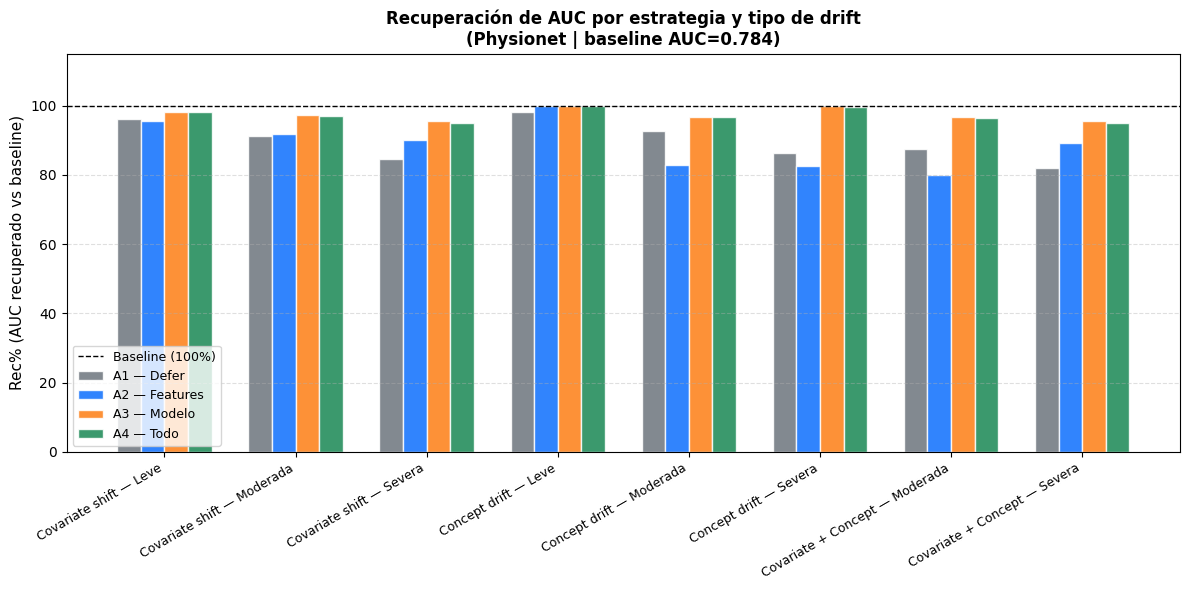

In [ ]:
COLORS = {
    "A1": "#6c757d",
    "A2": "#0d6efd",
    "A2c": "#20c997",
    "A3": "#fd7e14",
    "A4": "#198754",
}
LABELS = {
    "A1": "A1 — Defer",
    "A2": "A2 — QT refit",
    "A2c": "A2c — Corrective",
    "A3": "A3 — Modelo",
    "A4": "A4 — Todo",
}
SERIES = [
    ("A1", "A1 Rec%"),
    ("A2", "A2 Rec%"),
    ("A2c", "A2c Rec%"),
    ("A3", "A3 Rec%"),
    ("A4", "A4 Rec%"),
]

df_plot = df_results.copy()
df_plot["label"] = df_plot["Condicion"] + " — " + df_plot["Sev."]
labels = df_plot["label"].tolist()
n = len(labels)
x = np.arange(n)
w = 0.14

fig, ax = plt.subplots(figsize=(max(12, n * 1.6), 6))

for i, (key, col) in enumerate(SERIES):
    offset = (i - (len(SERIES) - 1) / 2) * w
    ax.bar(
        x + offset,
        df_plot[col],
        w,
        label=LABELS[key],
        color=COLORS[key],
        alpha=0.85,
        edgecolor="white",
    )

ax.axhline(100, color="black", linestyle="--", lw=1, label="Baseline (100%)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Rec% (AUC recuperado vs baseline)", fontsize=11)
ax.set_title(
    "Recuperación de AUC por estrategia y tipo de drift\n"
    f"(Physionet | baseline AUC={AUC_BASE:.3f})",
    fontweight="bold",
    fontsize=12,
)
ax.legend(loc="lower left", fontsize=9)
ax.set_ylim(0, 115)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Visualización de drift en VITALS (severidad Moderada)

Efecto del covariate drift (sev=0.5) sobre las distribuciones de los signos vitales.


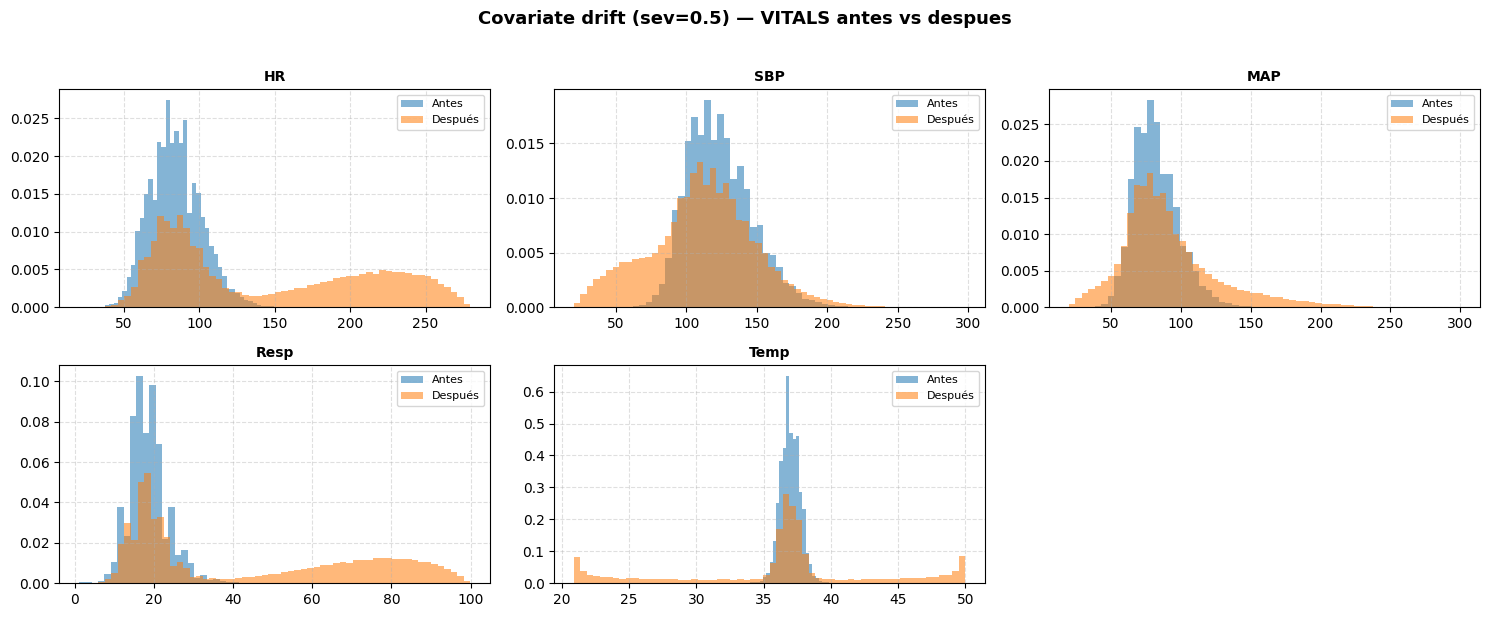

In [ ]:
df_d_vis, _ = inj.transform(
    df_target,
    drift_severity=0.5,
    numeric_drift_config=NUM_CFG,
    drift_type="covariate",
)

fig = plot_numeric_drift_grid(df_target, df_d_vis, cols=VITALS, ncols=3, bins=60)
plt.suptitle(
    "Covariate drift (sev=0.5) — VITALS antes vs despues",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 11. Conclusiones

La tabla resume el patrón esperado del framework **DARL**:

| Tipo de drift   | Etapa afectada          | Estrategia óptima esperada  |
| --------------- | ----------------------- | --------------------------- |
| Covariate shift | Stage 1 — Preprocessing | **A2** (reajustar features) |
| Concept drift   | Stage 2 — Modelo        | **A3** (reentrenar modelo)  |
| Ambos           | Stage 1 + Stage 2       | **A4** (reentrenar todo)    |

El objetivo de DARL es **diagnosticar automáticamente** el tipo de drift
para seleccionar la estrategia óptima sin intervención manual,
minimizando el costo de actualización mientras se maximiza la recuperación de rendimiento.
